# Car Rental Transformed Analytics
This notebook performs 20 practical transformation scenarios on `car_rental_cleaned_dataset.csv`.

Notes:
- Some use-cases (scheduled SLA, add-ons, subscription) are not directly available in source columns, so lightweight, clearly-labeled proxy assumptions are used.
- The focus is simple, reproducible transformation logic using pandas/numpy with quick visuals via matplotlib/seaborn.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

df = pd.read_csv("car_rental_cleaned_dataset.csv")

required_defaults = {
    "Reservation_ID": "",
    "Customer_ID": "",
    "Vehicle_ID": "",
    "Vehicle_Class": "Unknown",
    "Booking_Status": "Unknown",
    "Booking_TS": pd.NaT,
    "Pickup_TS": pd.NaT,
    "Return_TS": pd.NaT,
    "Odo_Start": np.nan,
    "Odo_End": np.nan,
    "Fuel_Level": np.nan,
    "Rate": np.nan,
    "Promo_Code": "",
    "City": "Unknown",
    "GPS_Lat": np.nan,
    "GPS_Lon": np.nan,
    "Speed": np.nan,
    "Damage_Flag": "None",
    "Notes": "",
    "Vehicle_ID_Invalid": False,
    "Duration_Hours": np.nan,
    "Distance_Driven": np.nan,
    "Refuel_Event": "",
    "Driver_Behavior": "Unknown",
    "Total_Amount": np.nan,
}
for col, default in required_defaults.items():
    if col not in df.columns:
        df[col] = default

for col in ["Booking_TS", "Pickup_TS", "Return_TS", "Prev_Return", "Promo_Expiry"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

for col in ["Duration_Hours", "Distance_Driven", "Odo_Start", "Odo_End", "Rate", "Total_Amount", "Fuel_Level", "Speed", "GPS_Lat", "GPS_Lon"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

bool_values = df["Vehicle_ID_Invalid"].astype(str).str.lower().str.strip()
df["vehicle_id_invalid_flag"] = bool_values.isin(["true", "1", "yes"])

df["is_completed"] = df["Booking_Status"].eq("Completed")
df["rental_hours"] = df["Duration_Hours"]
mask_missing_hours = df["rental_hours"].isna() & df["Pickup_TS"].notna() & df["Return_TS"].notna()
df.loc[mask_missing_hours, "rental_hours"] = (
    (df.loc[mask_missing_hours, "Return_TS"] - df.loc[mask_missing_hours, "Pickup_TS"]).dt.total_seconds() / 3600
)
df["rental_hours"] = df["rental_hours"].clip(lower=0)

df["distance_km"] = df["Distance_Driven"].clip(lower=0)
df["lead_time_hours"] = ((df["Pickup_TS"] - df["Booking_TS"]).dt.total_seconds() / 3600).clip(lower=0)
df["booking_month"] = df["Booking_TS"].dt.to_period("M").astype(str)
df["pickup_date"] = df["Pickup_TS"].dt.date

a_start = df["Pickup_TS"].min()
a_end = df["Return_TS"].max()
analysis_hours = max((a_end - a_start).total_seconds() / 3600, 1) if pd.notna(a_start) and pd.notna(a_end) else 1

print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print(f"Analysis window hours: {analysis_hours:,.2f}")
print(df[["Reservation_ID", "City", "Vehicle_Class", "Booking_Status", "rental_hours", "distance_km", "Rate", "Total_Amount"]].head())


Rows: 4,527 | Columns: 38
Analysis window hours: 8,159.15
  Reservation_ID     City Vehicle_Class Booking_Status  rental_hours  \
0      RES-00003    Delhi        Suzuki      Completed          71.0   
1      RES-03655   Mumbai        Suzuki      Completed          28.0   
2      RES-01774   Mumbai        Suzuki      Cancelled           3.0   
3      RES-03809  Chennai        Suzuki      Cancelled          38.0   
4      RES-01293   Mumbai        Suzuki      Cancelled        2163.0   

   distance_km    Rate  Total_Amount  
0        382.0  2000.0        2360.0  
1        211.0  2300.0        2714.0  
2          0.0  1840.0           0.0  
3          0.0  2000.0           0.0  
4          0.0  1500.0           0.0  


## 1) Utilization = rental hours / fleet hours by city and vehicle class


         City Vehicle_Class  available_cars    fleet_hours  rental_hours  \
20      Delhi           SUV              13   76309.394412      57835.44   
7   Bengaluru        Toyota              10   56872.983333      42669.97   
13    Chennai         Sedan              15   83321.066667      54094.13   
31     Mumbai        Toyota              17   98207.233333      59256.75   
14    Chennai        Suzuki               9   56079.766667      32709.91   
28     Mumbai           SUV              18  104014.066667      56395.49   
9     Chennai            EV               9   56481.716667      27611.10   
3   Bengaluru        Luxury              17   95908.350000      42585.52   
10    Chennai     Hatchback              16   95115.066667      40584.26   
15    Chennai        Toyota              13   79469.716667      33437.33   
24     Mumbai         Creta              18  108194.766667      45352.39   
21      Delhi         Sedan              29  182665.416667      73512.57   

    utiliza

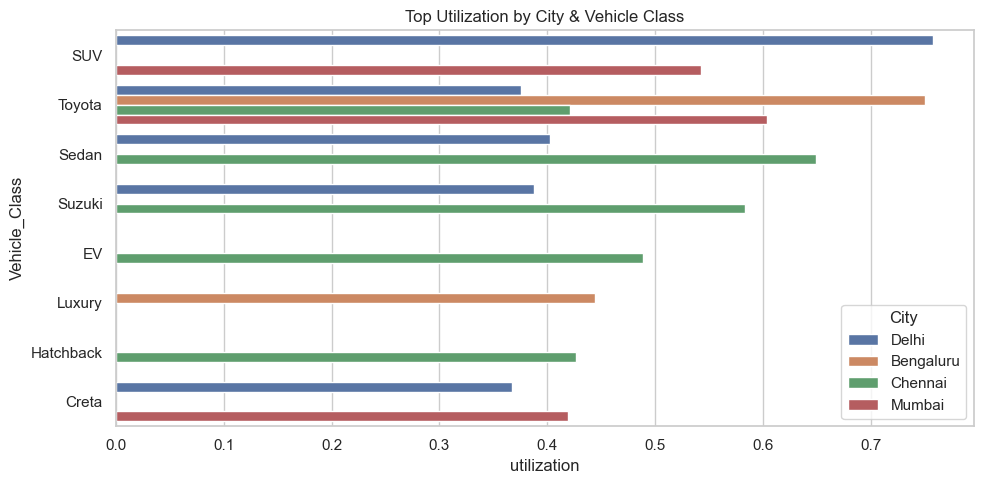

In [3]:
vehicle_activity = df.groupby("Vehicle_ID").agg(
    first_use=("Pickup_TS", "min"),
    last_use=("Return_TS", "max"),
    City=("City", "first"),
    Vehicle_Class=("Vehicle_Class", "first")
).reset_index()

vehicle_activity["active_hours"] = (
    vehicle_activity["last_use"] - vehicle_activity["first_use"]
).dt.total_seconds() / 3600

fleet = vehicle_activity.groupby(["City", "Vehicle_Class"], dropna=False).agg(
    available_cars=("Vehicle_ID", "nunique"),
    fleet_hours=("active_hours", "sum")
)

rental = df.loc[df["is_completed"]].groupby(
    ["City", "Vehicle_Class"], dropna=False
)["rental_hours"].sum().rename("rental_hours")

util = pd.concat([fleet, rental], axis=1).fillna(0).reset_index()

util["utilization"] = np.where(
    util["fleet_hours"] > 0,
    util["rental_hours"] / util["fleet_hours"],
    0
)

util = util.sort_values("utilization", ascending=False)

print(util.head(12))

plt.figure(figsize=(10, 5))
sns.barplot(data=util.head(15), x="utilization", y="Vehicle_Class", hue="City")
plt.title("Top Utilization by City & Vehicle Class")
plt.tight_layout()
plt.show()

## 2) Revenue per available car (RevPAC) and yield metrics


In [4]:
completed = df[df["is_completed"]].copy()
completed = completed[(completed["Rate"] > 0) & completed["rental_hours"].notna()].copy()

# Rate is daily; convert to hourly and cap extreme durations for proxy stability
max_billable_hours = 240
completed["billable_hours_proxy"] = completed["rental_hours"].clip(lower=0, upper=max_billable_hours)
completed["base_bill_with_tax"] = (completed["Rate"] / 24) * completed["billable_hours_proxy"] * 1.18
completed["long_rental_review_flag"] = completed["rental_hours"] > max_billable_hours

# aggregate metrics
metrics = completed.groupby(["City", "Vehicle_Class"], dropna=False).agg(
    revenue=("Total_Amount", "sum"),
    rental_hours=("rental_hours", "sum"),
    base_revenue_proxy=("base_bill_with_tax", "sum"),
    trips=("Reservation_ID", "count"),
    long_rental_reviews=("long_rental_review_flag", "sum"),
).reset_index()

# merge with fleet availability
rev_metrics = util[["City", "Vehicle_Class", "available_cars"]].merge(
    metrics,
    on=["City", "Vehicle_Class"],
    how="left"
).fillna(0)

# RevPAC = revenue per available car
rev_metrics["RevPAC"] = np.where(
    rev_metrics["available_cars"] > 0,
    rev_metrics["revenue"] / rev_metrics["available_cars"],
    0,
)

# yield per rental hour
rev_metrics["yield_per_hour"] = np.where(
    rev_metrics["rental_hours"] > 0,
    rev_metrics["revenue"] / rev_metrics["rental_hours"],
    0,
)

# realization vs expected revenue proxy (tax-inclusive)
rev_metrics["realization_vs_base"] = np.where(
    rev_metrics["base_revenue_proxy"] > 0,
    rev_metrics["revenue"] / rev_metrics["base_revenue_proxy"],
    np.nan,
)

print(rev_metrics.sort_values("RevPAC", ascending=False).head(12))

         City Vehicle_Class  available_cars    revenue  rental_hours  \
0       Delhi           SUV              13  145779.68      57835.44   
4     Chennai        Suzuki               9   71203.06      32709.91   
1   Bengaluru        Toyota              10   78188.66      42669.97   
6     Chennai            EV               9   64429.24      27611.10   
12      Delhi        Suzuki              19  125812.84      41519.65   
9     Chennai        Toyota              13   82107.50      33437.33   
10     Mumbai         Creta              18  113094.92      45352.39   
2     Chennai         Sedan              15   94165.24      54094.13   
19      Delhi     Hatchback              27  160812.88      54127.42   
7   Bengaluru        Luxury              17   97871.68      42585.52   
30     Mumbai            EV              15   83119.82      16667.18   
3      Mumbai        Toyota              17   92304.56      59256.75   

    base_revenue_proxy  trips  long_rental_reviews        RevPA

## 3) Distance driven and cost per km


         City Vehicle_Class  total_distance_km  weighted_cost_per_km  \
16      Delhi         Creta            15750.0              9.047455   
21      Delhi         Sedan            15628.0              9.144034   
23      Delhi        Toyota            15356.0              9.522497   
18      Delhi     Hatchback            14889.0             10.390253   
20      Delhi           SUV            13842.0              9.893994   
26     Mumbai     Hatchback            13419.0              8.129129   
24     Mumbai         Creta            13216.0              8.173496   
17      Delhi            EV            12022.0              9.485904   
3   Bengaluru        Luxury            11334.0              8.479061   
5   Bengaluru         Sedan            11066.0              7.564652   
19      Delhi        Luxury            10250.0             10.305838   
22      Delhi        Suzuki            10040.0             10.998570   

    median_cost_per_km  trips  
16            9.440000     67  

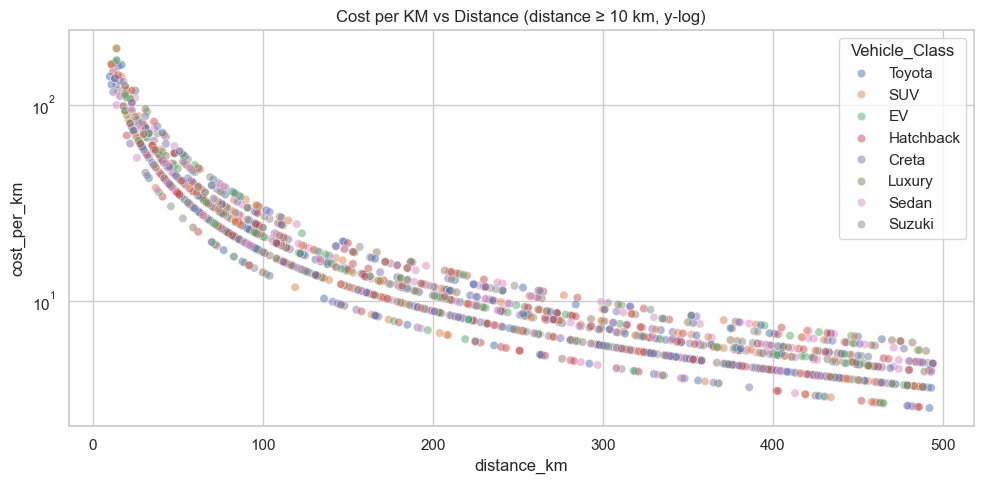

In [5]:
min_distance_km = 10

trip = df[(df["is_completed"]) & (df["distance_km"] >= min_distance_km) & (df["Total_Amount"] > 0)].copy()

# remove extreme distance outliers
trip = trip[trip["distance_km"] <= trip["distance_km"].quantile(0.99)]

trip["cost_per_km"] = trip["Total_Amount"] / trip["distance_km"]

plot_cap = trip["cost_per_km"].quantile(0.99) if len(trip) else np.nan
trip_plot = trip[trip["cost_per_km"] <= plot_cap].copy() if pd.notna(plot_cap) else trip.copy()

distance_cost = trip.groupby(["City", "Vehicle_Class"], dropna=False).agg(
    total_distance_km=("distance_km", "sum"),
    weighted_cost_per_km=("Total_Amount", lambda s: s.sum() / trip.loc[s.index, "distance_km"].sum()),
    median_cost_per_km=("cost_per_km", "median"),
    trips=("Reservation_ID", "count"),
).reset_index().sort_values("total_distance_km", ascending=False)

print(distance_cost.head(12))

plt.figure(figsize=(10,5))
sns.scatterplot(
    data=trip_plot.sample(min(len(trip_plot), 2000), random_state=42),
    x="distance_km",
    y="cost_per_km",
    hue="Vehicle_Class",
    alpha=0.5
)

plt.yscale("log")
plt.title("Cost per KM vs Distance (distance ≥ 10 km, y-log)")
plt.xlabel("distance_km")
plt.ylabel("cost_per_km")

plt.tight_layout()
plt.show()

## 4) Idle time and repositioning analytics


In [6]:
# sort trips by vehicle and pickup time
seq = df.sort_values(["Vehicle_ID", "Pickup_TS"])

# get previous trip return time and city for the same vehicle
seq["prev_return_ts"] = seq.groupby("Vehicle_ID")["Return_TS"].shift()
seq["prev_city"] = seq.groupby("Vehicle_ID")["City"].shift()

# calculate idle time between trips
seq["idle_hours"] = (seq["Pickup_TS"] - seq["prev_return_ts"]).dt.total_seconds() / 3600
seq["idle_hours"] = seq["idle_hours"].clip(lower=0)

# check if vehicle moved to a different city
seq["repositioned"] = (seq["City"] != seq["prev_city"]) & seq["prev_city"].notna()

# summarize idle behaviour per vehicle
idle_summary = seq.groupby("Vehicle_ID").agg(
    avg_idle_hours=("idle_hours", "mean"),
    median_idle_hours=("idle_hours", "median"),
    reposition_events=("repositioned", "sum")
).reset_index()

# show vehicles with highest idle time
print(idle_summary.sort_values("avg_idle_hours", ascending=False).head(10))
print(idle_summary.shape)


    Vehicle_ID  avg_idle_hours  median_idle_hours  reposition_events
117    CAR-118     4095.250000        4095.250000                  1
33     CAR-035     2764.741667        2764.741667                  2
547    CAR-548     2596.966667        2596.966667                  1
147    CAR-148     2518.455556        2938.016667                  1
288    CAR-289     2489.950000        2489.950000                  1
115    CAR-116     2465.283333        2465.283333                  1
340    CAR-341     2287.816667        2287.816667                  0
130    CAR-131     2090.075000        2090.075000                  0
370    CAR-371     1929.975000        1929.975000                  1
395    CAR-396     1828.804167         814.458333                  3
(600, 4)


## 5) Dynamic pricing features (demand, lead time, seasonality)


  Reservation_ID     City Vehicle_Class     Rate  lead_time_hours  \
0      RES-00003    Delhi        Suzuki  2000.00             24.0   
1      RES-03655   Mumbai        Suzuki  2300.00             24.0   
2      RES-01774   Mumbai        Suzuki  1840.00             48.0   
3      RES-03809  Chennai        Suzuki  2000.00            216.0   
4      RES-01293   Mumbai        Suzuki  1500.00           2952.0   
5      RES-02593    Delhi        Suzuki  2300.00           1488.0   
6      RES-01461    Delhi        Toyota  1835.27            216.0   
7      RES-02265   Mumbai        Toyota  2000.00            216.0   
8      RES-03309   Mumbai        Toyota  1500.00             24.0   
9      RES-02194  Chennai        Toyota  1500.00             24.0   

   daily_demand  month    weekday  
0             4      3     Monday  
1            14      4     Sunday  
2             6      4    Tuesday  
3             4      6   Saturday  
4             1      9     Monday  
5             9      9  

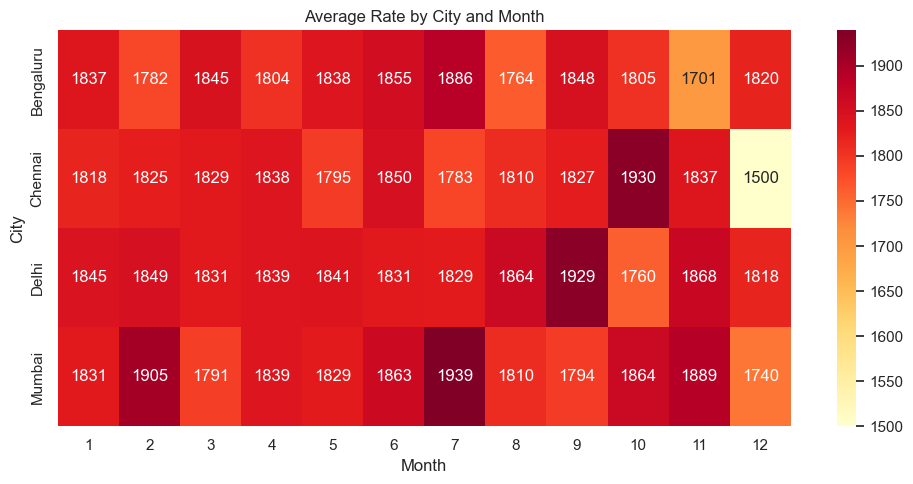

In [7]:
#TRANFORM 5

pricing = df.copy()

pricing["month"] = pricing["Pickup_TS"].dt.month
pricing["weekday"] = pricing["Pickup_TS"].dt.day_name()

pricing["daily_demand"] = pricing.groupby(["City", "pickup_date"])["Reservation_ID"].transform("count")

print(pricing[["Reservation_ID","City","Vehicle_Class","Rate","lead_time_hours","daily_demand","month","weekday"]].head(10))

plt.figure(figsize=(10,5))

heat_data = pricing.pivot_table(
    values="Rate",
    index="City",
    columns="month",
    aggfunc="mean"
)

sns.heatmap(
    heat_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f"
)

plt.title("Average Rate by City and Month")
plt.xlabel("Month")
plt.ylabel("City")

plt.tight_layout()
plt.show()


## 6) Fuel efficiency estimates by model (proxy using Vehicle_Class)


In [8]:
fuel = df[(df["is_completed"]) & (df["distance_km"] > 0)].copy()

fuel["fuel_used_proxy"] = (
    1 - fuel["Fuel_Level"].fillna(fuel["Fuel_Level"].median())
).clip(0.05, 1)

fuel["fuel_efficiency_proxy"] = fuel["distance_km"] / fuel["fuel_used_proxy"]

fuel_eff = fuel.groupby("Vehicle_Class", dropna=False).agg(
    trips=("Reservation_ID", "count"),
    avg_fuel_efficiency=("fuel_efficiency_proxy", "mean"),
    median_fuel_efficiency=("fuel_efficiency_proxy", "median")
).round(2).reset_index().sort_values("avg_fuel_efficiency", ascending=False)

print(fuel_eff)


  Vehicle_Class  trips  avg_fuel_efficiency  median_fuel_efficiency
3        Luxury    163              1166.27                  498.67
6        Suzuki    181              1162.61                  426.00
0         Creta    210              1054.67                  462.65
7        Toyota    191               972.36                  460.00
5         Sedan    191               905.45                  424.29
2     Hatchback    212               811.67                  397.33
4           SUV    171               791.95                  416.00
1            EV    165               733.64                  369.39


## 7) Damage incidence rate per 100 rentals


In [9]:
damage = df.copy()

damage["damage_event"] = damage["Damage_Flag"].fillna("None") != "None"

damage_rate = damage.groupby(["City", "Vehicle_Class"]).agg(
    rentals=("Reservation_ID", "count"),
    damage_events=("damage_event", "sum")
).reset_index()

damage_rate["damage_per_100_rentals"] = (
    100 * damage_rate["damage_events"] / damage_rate["rentals"]
).round(2)

print(damage_rate.sort_values("damage_per_100_rentals", ascending=False).head(10))

         City Vehicle_Class  rentals  damage_events  damage_per_100_rentals
7   Bengaluru        Toyota      117             91                   77.78
13    Chennai         Sedan      111             82                   73.87
27     Mumbai        Luxury      108             79                   73.15
1   Bengaluru            EV      128             93                   72.66
29     Mumbai         Sedan      117             84                   71.79
31     Mumbai        Toyota      145            103                   71.03
24     Mumbai         Creta      187            132                   70.59
12    Chennai           SUV       80             56                   70.00
30     Mumbai        Suzuki      129             90                   69.77
14    Chennai        Suzuki       94             65                   69.15


## 8) Customer cohort retention and NPS rollups


In [10]:
cust = df[df["is_completed"]].copy()
cust["booking_month_period"] = cust["Booking_TS"].dt.to_period("M")
cohort_month = cust.groupby("Customer_ID")["booking_month_period"].min().rename("cohort_month")
cust = cust.join(cohort_month, on="Customer_ID")

valid = cust.dropna(subset=["booking_month_period", "cohort_month"]).copy()
valid["cohort_index"] = valid["booking_month_period"].astype(int) - valid["cohort_month"].astype(int)

ret_counts = valid.groupby(["cohort_month", "cohort_index"])["Customer_ID"].nunique().unstack(fill_value=0)
if not ret_counts.empty:
    base = ret_counts.iloc[:, 0]
    retention = ret_counts.div(base, axis=0).round(3)
    print("Retention matrix (first rows):")
    print(retention.head())
else:
    print("Retention matrix unavailable (insufficient date data).")

valid["nps_bucket"] = np.select(
    [
        (valid["Driver_Behavior"].eq("Normal Driving") & valid["Damage_Flag"].eq("None")),
        (valid["Driver_Behavior"].isin(["Speeding", "Fast Driving"]) | valid["Damage_Flag"].eq("Major")),
    ],
    ["Promoter", "Detractor"],
    default="Passive",
)

nps_rollup = valid.groupby("cohort_month")["nps_bucket"].value_counts(normalize=True).unstack(fill_value=0)
nps_rollup["NPS"] = (nps_rollup.get("Promoter", 0) - nps_rollup.get("Detractor", 0)) * 100
print("\nNPS by cohort month:")
print(nps_rollup[[c for c in ["Promoter", "Passive", "Detractor", "NPS"] if c in nps_rollup.columns]].head(12))


Retention matrix (first rows):
cohort_index   0      1      2      3      4      5      6      7      8   \
cohort_month                                                                
2024-12       1.0  0.065  0.087  0.109  0.065  0.109  0.043  0.000  0.000   
2025-01       1.0  0.088  0.120  0.085  0.095  0.095  0.007  0.000  0.000   
2025-02       1.0  0.155  0.130  0.110  0.080  0.000  0.000  0.005  0.005   
2025-03       1.0  0.078  0.067  0.106  0.011  0.000  0.000  0.000  0.000   
2025-04       1.0  0.085  0.071  0.000  0.000  0.000  0.000  0.000  0.000   

cohort_index     9      10  
cohort_month                
2024-12       0.000  0.022  
2025-01       0.000  0.000  
2025-02       0.005  0.000  
2025-03       0.000  0.000  
2025-04       0.000  0.000  

NPS by cohort month:
nps_bucket     Passive  Detractor         NPS
cohort_month                                 
2024-12       0.309859   0.690141  -69.014085
2025-01       0.301762   0.698238  -69.823789
2025-02       0.3166

## 9) Fraud risk score (short returns, odometer anomalies)


In [11]:
#TRANSFORM 9 --> Fraud risk score (short returns, odometer anomalies).

fraud = df.copy()

# Flag 1: Short rental return (completed trips less than 2 hours)
# Simplified condition but logic remains the same
fraud["short_return_flag"] = (fraud["is_completed"]) & (fraud["rental_hours"] < 2)

# Odometer difference
# Created once so it can be reused in anomaly detection
fraud["odo_diff"] = fraud["Odo_End"] - fraud["Odo_Start"]

# Flag 2: Odometer anomaly
# Detect if odometer decreases OR mismatch with recorded distance
fraud["odo_anomaly_flag"] = (fraud["odo_diff"] < 0) | ((fraud["odo_diff"] - fraud["distance_km"]).abs() > 50)

# Flag 3: Speed risk
# Simple threshold rule for abnormal driving speed
fraud["speed_risk_flag"] = fraud["Speed"] > 120

# Fraud risk score
# Weights assigned based on severity of anomaly
fraud["fraud_risk_score"] = (
    30 * fraud["short_return_flag"].astype(int) +     # short return risk
    50 * fraud["odo_anomaly_flag"].fillna(False).astype(int) +   # major anomaly
    20 * fraud["speed_risk_flag"].fillna(False).astype(int) +    # overspeeding
    20 * fraud["vehicle_id_invalid_flag"].astype(int)            # invalid vehicle ID
).clip(0, 100)   # keep score within 0–100

# Final fraud monitoring view
# Selected only relevant columns for easier inspection
fraud_view = fraud[["Reservation_ID","Customer_ID","Vehicle_ID","City","fraud_risk_score","short_return_flag","odo_anomaly_flag","speed_risk_flag","vehicle_id_invalid_flag"]]

# Show highest risk reservations
print(fraud_view.sort_values("fraud_risk_score", ascending=False).head(20))

     Reservation_ID Customer_ID Vehicle_ID       City  fraud_risk_score  \
1638      RES-02411   CUST-1091    CAR-221     Mumbai                50   
1179      RES-00705   CUST-1275    CAR-161  Bengaluru                50   
162       RES-00587   CUST-0711    CAR-022     Mumbai                50   
65        RES-04387   CUST-0081    CAR-010      Delhi                50   
2761      RES-02492   CUST-1845    CAR-368      Delhi                50   
2906      RES-03534   CUST-0054    CAR-388    Chennai                50   
207       RES-02627   CUST-1521    CAR-027     Mumbai                50   
2469      RES-02750   CUST-0798    CAR-334  Bengaluru                50   
3044      RES-02534   CUST-1429    CAR-407     Mumbai                50   
4515      RES-01041   CUST-0416    CAR-600    Chennai                40   
4520      RES-00590   CUST-1291    CAR-600      Delhi                40   
4517      RES-03681   CUST-1584    CAR-600     Mumbai                40   
1521      RES-02088   CUS

## 10) Maintenance due forecast (km/time based)


In [12]:
# Filter to Completed trips only — odometer readings are only meaningful here
df_completed = df[df["Booking_Status"] == "Completed"]

latest = (
    df_completed
    .sort_values("Return_TS")
    .groupby("Vehicle_ID", as_index=False)
    .tail(1)
    .copy()
)

latest["current_odometer"] = latest["Odo_End"].fillna(latest["Odo_Start"])
latest["km_to_next_service"] = 10000 - (latest["current_odometer"] % 10000)
latest["days_since_last_return"] = (
    pd.Timestamp.today().normalize() - latest["Return_TS"]
).dt.days

latest["maintenance_due"] = (
    (latest["km_to_next_service"] <= 500) | (latest["days_since_last_return"] >= 180)
)

# Fix: clip days score at 1, not 2, so final score stays in [0, 1]
latest["maintenance_priority"] = (
    ((500 - latest["km_to_next_service"]).clip(lower=0) / 500) * 0.6
    + (latest["days_since_last_return"].clip(lower=0) / 180).clip(upper=1) * 0.4
)

print(
    latest[[
        "Vehicle_ID", "Vehicle_Class", "current_odometer",
        "km_to_next_service", "days_since_last_return",
        "maintenance_due", "maintenance_priority"
    ]]
    .sort_values(["maintenance_due", "maintenance_priority"], ascending=[False, False])
    .head(20)
)

     Vehicle_ID Vehicle_Class  current_odometer  km_to_next_service  \
1257    CAR-173        Suzuki           59935.0                65.0   
1361    CAR-186        Toyota           69928.0                72.0   
4378    CAR-582        Suzuki           59910.0                90.0   
4267    CAR-567         Sedan           49894.0               106.0   
1106    CAR-153        Toyota           49870.0               130.0   
4128    CAR-552         Sedan           59864.0               136.0   
1519    CAR-207     Hatchback           59952.0                48.0   
3446    CAR-463        Suzuki           69911.0                89.0   
4027    CAR-539         Creta           29809.0               191.0   
403     CAR-051         Creta           29956.0                44.0   
3640    CAR-489        Luxury           19801.0               199.0   
4063    CAR-544         Creta           29769.0               231.0   
1368    CAR-187            EV           69767.0               233.0   
2506  

## 11) Overstay detection and penalty calculation


In [13]:
overstay = df[df["is_completed"]].copy()
overstay = overstay[(overstay["Rate"] > 0) & overstay["rental_hours"].notna()].copy()

# Rate is daily in this dataset; convert to hourly basis for penalties
overstay["hourly_rate"] = overstay["Rate"] / 24

# Bill-derived expected hours (fallback to 24h package when billing is synthetic)
overstay["expected_hours_from_bill"] = ((overstay["Total_Amount"] / 1.18) / overstay["Rate"]) * 24
overstay["expected_hours_from_bill"] = (
    overstay["expected_hours_from_bill"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(24)
    .clip(lower=4, upper=72)
)

grace_hours = 2
overstay["overstay_hours"] = (
    overstay["rental_hours"] - overstay["expected_hours_from_bill"] - grace_hours
).clip(lower=0)

# Split normal cases vs anomalous long durations
max_auto_bill_hours = 240  # >10 days should be manually investigated
overstay["manual_review_flag"] = overstay["rental_hours"] > max_auto_bill_hours

# Cap billable overstay for automatic penalty calculation
overstay["overstay_hours_capped"] = overstay["overstay_hours"].clip(upper=72)
h = overstay["overstay_hours_capped"]

overstay["penalty_first_6h"] = np.minimum(h, 6) * 0.25 * overstay["hourly_rate"]
overstay["penalty_next_18h"] = np.minimum(np.clip(h - 6, 0, None), 18) * 0.50 * overstay["hourly_rate"]
overstay["penalty_after_24h"] = np.clip(h - 24, 0, None) * 1.00 * overstay["hourly_rate"]

overstay["overstay_penalty"] = (
    overstay["penalty_first_6h"]
    + overstay["penalty_next_18h"]
    + overstay["penalty_after_24h"]
)

# Final hard cap: penalty cannot exceed 125% of one-day rate
overstay["overstay_penalty"] = np.minimum(overstay["overstay_penalty"], overstay["Rate"] * 1.25)

# Do not auto-penalize anomalous records; escalate for manual review
overstay.loc[overstay["manual_review_flag"], "overstay_penalty"] = np.nan

print(f"Manual review rows: {overstay['manual_review_flag'].sum():,} / {len(overstay):,}")
print(overstay[[
    "Reservation_ID", "City", "expected_hours_from_bill",
    "overstay_hours", "overstay_penalty", "manual_review_flag"
]].sort_values("overstay_penalty", ascending=False, na_position="last").head(20))

Manual review rows: 551 / 1,487
     Reservation_ID       City  expected_hours_from_bill  overstay_hours  \
3914      RES-03224     Mumbai                      24.0           45.00   
1441      RES-02189      Delhi                      24.0           43.00   
993       RES-04323    Chennai                      24.0           43.00   
730       RES-03698      Delhi                      24.0           42.00   
35        RES-03934  Bengaluru                      24.0           42.95   
2840      RES-03019      Delhi                      24.0           42.00   
2851      RES-02699  Bengaluru                      24.0           39.00   
4023      RES-03182      Delhi                      24.0           40.00   
2594      RES-04411      Delhi                      24.0           40.00   
864       RES-03862     Mumbai                      24.0           39.87   
0         RES-00003      Delhi                      24.0           45.00   
3361      RES-02873  Bengaluru                      24.0

## 12) Pickup/return punctuality stats


Assumption for punctuality (proxy):
- `scheduled_pickup = Booking_TS + 24 hours`
- return punctuality is measured by difference between computed actual duration and provided duration field.


In [14]:
punct = df.copy()
punct["scheduled_pickup"] = punct["Booking_TS"] + pd.Timedelta(hours=24)
punct["pickup_delay_min"] = (punct["Pickup_TS"] - punct["scheduled_pickup"]).dt.total_seconds() / 60

punct["actual_duration_hours"] = (punct["Return_TS"] - punct["Pickup_TS"]).dt.total_seconds() / 3600
punct["return_delay_min"] = (punct["actual_duration_hours"] - punct["Duration_Hours"]).fillna(0) * 60

punct["pickup_on_time"] = punct["pickup_delay_min"].abs() <= 30
punct["return_on_time"] = punct["return_delay_min"].abs() <= 30

punct_stats = punct.groupby("City", dropna=False).agg(
    pickup_on_time_rate=("pickup_on_time", "mean"),
    return_on_time_rate=("return_on_time", "mean"),
    avg_pickup_delay_min=("pickup_delay_min", "mean"),
    avg_return_delay_min=("return_delay_min", "mean"),
).reset_index()

punct_stats["pickup_on_time_rate"] = (punct_stats["pickup_on_time_rate"] * 100).round(2)
punct_stats["return_on_time_rate"] = (punct_stats["return_on_time_rate"] * 100).round(2)
print(punct_stats.round(2))


        City  pickup_on_time_rate  return_on_time_rate  avg_pickup_delay_min  \
0  Bengaluru                32.66                98.75              38137.15   
1    Chennai                32.33                99.62              35148.42   
2      Delhi                35.59                99.39              37311.89   
3     Mumbai                32.89                99.43              30992.51   

   avg_return_delay_min  
0                623.46  
1                187.69  
2                306.85  
3                282.33  


## 13) Geo heatmaps of pickup/drop hotspots


Drop coordinates are not separately available; pickup geo points are used as hotspot proxy.


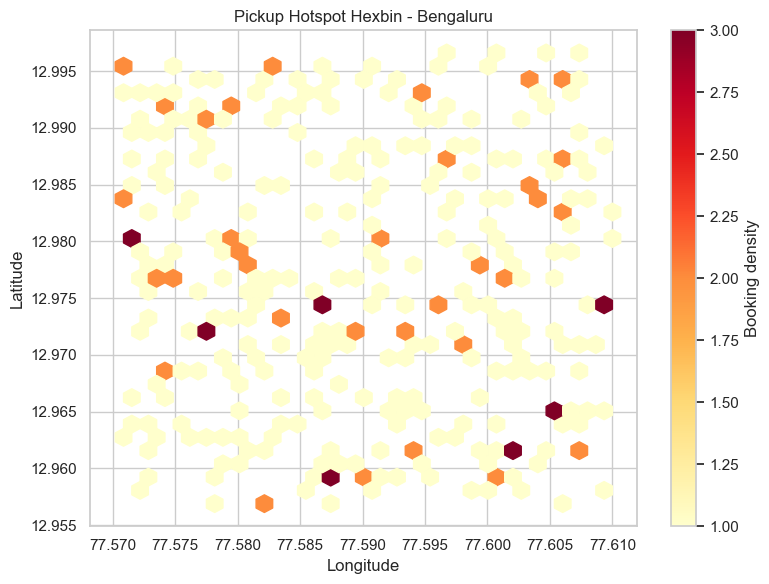

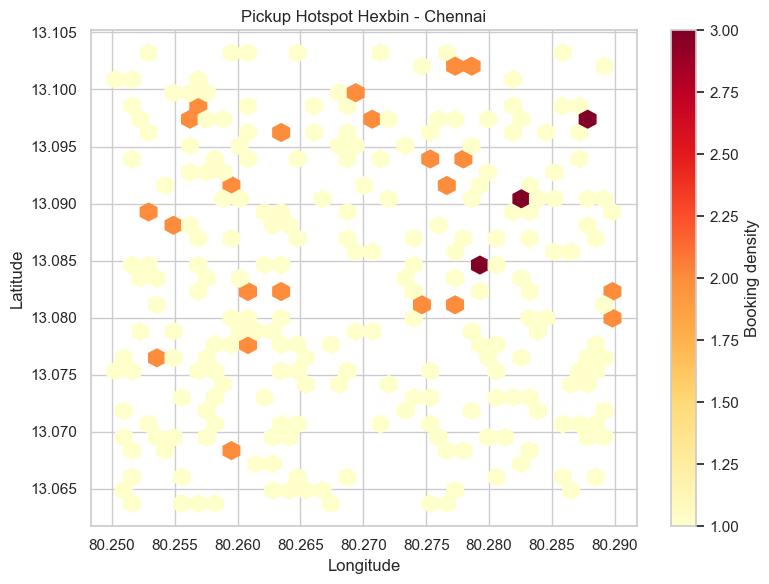

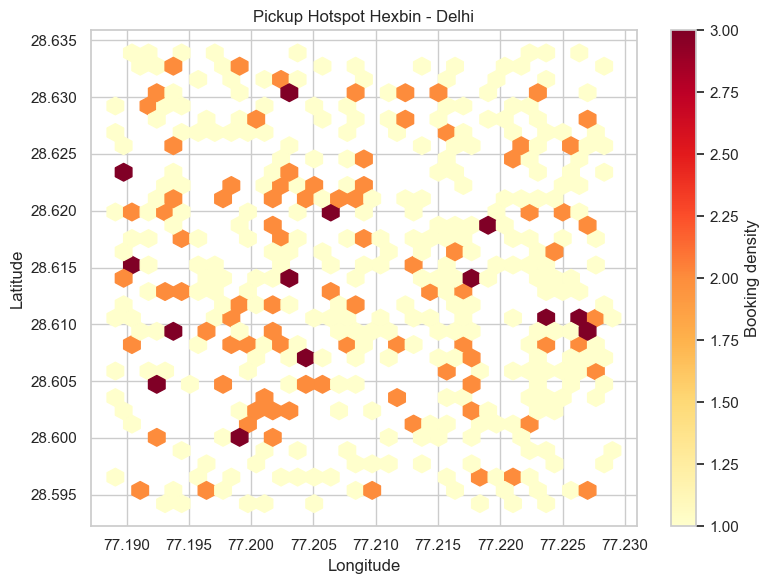

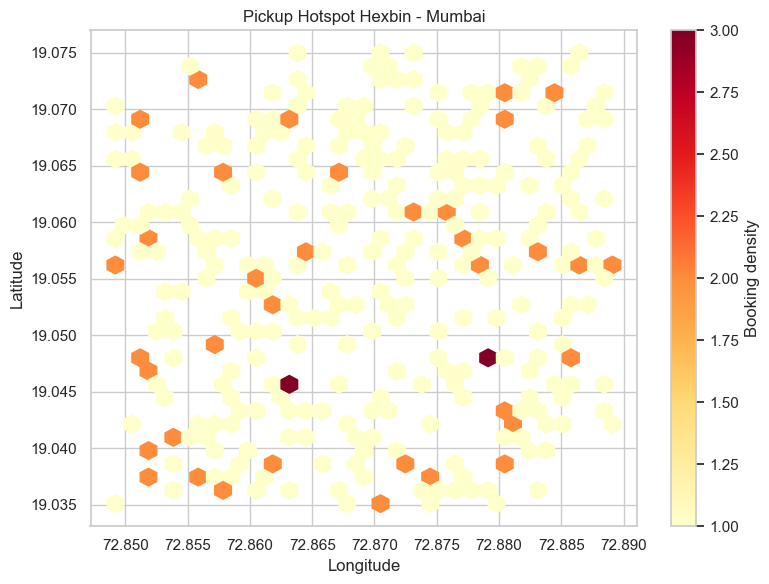

         City  lat_bin  lon_bin  bookings
61      Delhi    28.61    77.20        44
63      Delhi    28.61    77.22        43
68      Delhi    28.62    77.22        37
67      Delhi    28.62    77.21        36
58      Delhi    28.60    77.22        34
73      Delhi    28.63    77.22        32
56      Delhi    28.60    77.20        32
62      Delhi    28.61    77.21        31
66      Delhi    28.62    77.20        29
88     Mumbai    19.06    72.88        28
71      Delhi    28.63    77.20        27
76     Mumbai    19.04    72.86        27
36    Chennai    13.08    80.26        26
7   Bengaluru    12.97    77.59        25
65      Delhi    28.62    77.19        25


In [15]:
geo = df[df["is_completed"]].dropna(subset=["GPS_Lat", "GPS_Lon"]).copy()

# Heatmap per city
for city, data in geo.groupby("City"):

    plt.figure(figsize=(8, 6))
    plt.hexbin(data["GPS_Lon"], data["GPS_Lat"], gridsize=30, cmap="YlOrRd", mincnt=1)
    plt.colorbar(label="Booking density")

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Pickup Hotspot Hexbin - {city}")

    plt.tight_layout()
    plt.show()


# Identify hotspot zones
hotspots = (
    geo.assign(
        lat_bin=geo["GPS_Lat"].round(2),
        lon_bin=geo["GPS_Lon"].round(2)
    )
    .groupby(["City", "lat_bin", "lon_bin"], dropna=False)
    .size()
    .reset_index(name="bookings")
    .sort_values("bookings", ascending=False)
)

print(hotspots.head(15))

## 14) Upsell/cross-sell opportunity flags (addons)


In [16]:
upsell = df.copy()
notes = upsell["Notes"].fillna("").str.lower()

upsell["addon_navigation"] = notes.str.contains("navigation")
upsell["addon_cleaning"] = notes.str.contains("clean")
upsell["addon_fuel_plan"] = notes.str.contains("fuel") | (upsell["Fuel_Level"].fillna(0.5) < 0.25)
upsell["addon_protection"] = upsell["Driver_Behavior"].isin(["Speeding", "Fast Driving"]) | upsell["Damage_Flag"].isin(["Minor", "Major"])

flag_cols = ["addon_navigation", "addon_cleaning", "addon_fuel_plan", "addon_protection"]
upsell["upsell_flag_count"] = upsell[flag_cols].sum(axis=1)
upsell["upsell_opportunity"] = upsell["upsell_flag_count"] > 0

upsell_summary = upsell.groupby("City", dropna=False).agg(
    rentals=("Reservation_ID", "count"),
    opportunities=("upsell_opportunity", "sum"),
).reset_index()
upsell_summary["opportunity_rate"] = 100 * upsell_summary["opportunities"] / upsell_summary["rentals"]

print(upsell_summary.sort_values("opportunity_rate", ascending=False))


        City  rentals  opportunities  opportunity_rate
3     Mumbai     1061            953         89.820924
1    Chennai      798            714         89.473684
2      Delhi     1627           1443         88.690842
0  Bengaluru     1041            920         88.376561


## 15) Cancellation rate and reasons analysis


In [17]:
cancel = df.copy()
cancel["is_cancelled"] = cancel["Booking_Status"].isin(["Cancelled", "No_Show"])
notes = cancel["Notes"].fillna("").str.lower()

cancel["cancel_reason_bucket"] = np.select(
    [
        notes.str.contains("traffic"),
        notes.str.contains("fuel"),
        notes.str.contains("clean"),
        notes.str.contains("scratch|damage"),
        notes.str.contains("early pickup"),
        notes.str.contains("no notes"),
    ],
    ["Traffic", "Fuel", "Cleaning", "Damage Concern", "Schedule Change", "Unspecified"],
    default="Other",
)

cancel_rate = cancel.groupby(["City", "Vehicle_Class"], dropna=False).agg(
    total_bookings=("Reservation_ID", "count"),
    cancelled=("is_cancelled", "sum"),
).reset_index()
cancel_rate["cancellation_rate"] = 100 * cancel_rate["cancelled"] / cancel_rate["total_bookings"]

reason_dist = cancel[cancel["is_cancelled"]].groupby("cancel_reason_bucket").size().reset_index(name="count").sort_values("count", ascending=False)

print(cancel_rate.sort_values("cancellation_rate", ascending=False).head(12))
print("\nCancellation reason distribution:")
print(reason_dist)


         City Vehicle_Class  total_bookings  cancelled  cancellation_rate
19      Delhi        Luxury             189        139          73.544974
5   Bengaluru         Sedan             136         96          70.588235
24     Mumbai         Creta             187        132          70.588235
22      Delhi        Suzuki             200        141          70.500000
27     Mumbai        Luxury             108         76          70.370370
1   Bengaluru            EV             128         90          70.312500
2   Bengaluru     Hatchback             151        106          70.198675
29     Mumbai         Sedan             117         82          70.085470
12    Chennai           SUV              80         56          70.000000
31     Mumbai        Toyota             145        100          68.965517
8     Chennai         Creta             106         73          68.867925
0   Bengaluru         Creta             154        106          68.831169

Cancellation reason distribution:
  c

## 16) Driver behavior scoring from telematics


In [18]:
driver = df.copy()
driver["driver_score"] = 100

driver["driver_score"] = driver["driver_score"] - np.where(driver["Speed"] > 120, 30, np.where(driver["Speed"] > 100, 15, 0))
driver["driver_score"] = driver["driver_score"] - np.where(driver["Driver_Behavior"].eq("Speeding"), 25, np.where(driver["Driver_Behavior"].eq("Fast Driving"), 10, 0))
driver["driver_score"] = driver["driver_score"] - np.where(driver["Damage_Flag"].eq("Major"), 20, np.where(driver["Damage_Flag"].eq("Minor"), 8, 0))
driver["driver_score"] = driver["driver_score"].clip(lower=0, upper=100)

driver_summary = driver.groupby("Customer_ID", dropna=False).agg(
    trips=("Reservation_ID", "count"),
    avg_driver_score=("driver_score", "mean"),
).reset_index().sort_values("avg_driver_score")

print(driver_summary.head(20))


     Customer_ID  trips  avg_driver_score
1256   CUST-1388      1              25.0
811    CUST-0892      1              25.0
346    CUST-0375      1              25.0
717    CUST-0787      2              25.0
1683   CUST-1858      1              25.0
1673   CUST-1847      1              25.0
1170   CUST-1289      2              25.0
443    CUST-0483      1              25.0
143    CUST-0154      1              25.0
457    CUST-0497      2              25.0
967    CUST-1062      1              25.0
551    CUST-0596      1              25.0
1022   CUST-1126      1              25.0
1071   CUST-1179      1              25.0
596    CUST-0644      1              25.0
1580   CUST-1748      1              25.0
1478   CUST-1636      1              25.0
1276   CUST-1410      1              25.0
1020   CUST-1124      2              31.0
1460   CUST-1616      2              35.0


## 17) Vehicle class mix optimization


In [19]:
mix = util.merge(rev_metrics[["City", "Vehicle_Class", "RevPAC"]], on=["City", "Vehicle_Class"], how="left")
mix["fleet_share"] = mix.groupby("City")["available_cars"].transform(lambda s: s / max(s.sum(), 1))

mix["util_norm"] = mix.groupby("City")["utilization"].transform(lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9))
mix["rev_norm"] = mix.groupby("City")["RevPAC"].transform(lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9))
mix["mix_score"] = 0.6 * mix["util_norm"] + 0.4 * mix["rev_norm"]

mix["mix_action"] = np.where(mix["mix_score"] >= 0.66, "Increase share", np.where(mix["mix_score"] >= 0.33, "Hold / optimize", "Reduce share"))

print(mix.sort_values(["City", "mix_score"], ascending=[True, False]))


         City Vehicle_Class  available_cars    fleet_hours  rental_hours  \
1   Bengaluru        Toyota              10   56872.983333      42669.97   
7   Bengaluru        Luxury              17   95908.350000      42585.52   
18  Bengaluru           SUV              15   99447.000000      33577.08   
16  Bengaluru        Suzuki              20  108762.516667      37669.20   
22  Bengaluru     Hatchback              20  118916.466667      37369.52   
24  Bengaluru         Sedan              18  106025.683333      29979.12   
26  Bengaluru            EV              19  110097.650000      28665.80   
29  Bengaluru         Creta              24  146412.633333      34010.07   
4     Chennai        Suzuki               9   56079.766667      32709.91   
2     Chennai         Sedan              15   83321.066667      54094.13   
6     Chennai            EV               9   56481.716667      27611.10   
9     Chennai        Toyota              13   79469.716667      33437.33   
8     Chenna

## 18) Lead-time price elasticity features


          City Vehicle_Class lead_time_bucket  price_elasticity
53     Chennai        Suzuki              NaN        -44.129638
58       Delhi         Creta           Medium        -29.392037
35     Chennai     Hatchback           Medium        -14.079960
30     Chennai         Creta              NaN        -11.701732
24   Bengaluru        Toyota           Medium        -10.520131
14   Bengaluru           SUV           Medium         -9.510553
76       Delhi         Sedan           Medium         -9.061692
114     Mumbai        Toyota           Medium         -8.324030
64       Delhi            EV              NaN         -6.595402
87      Mumbai         Creta             Long         -5.811495
67       Delhi     Hatchback              NaN         -5.708576
88      Mumbai         Creta              NaN         -4.998957
91      Mumbai            EV             Long         -4.935071
6    Bengaluru            EV              NaN         -4.596140
69       Delhi        Luxury           M

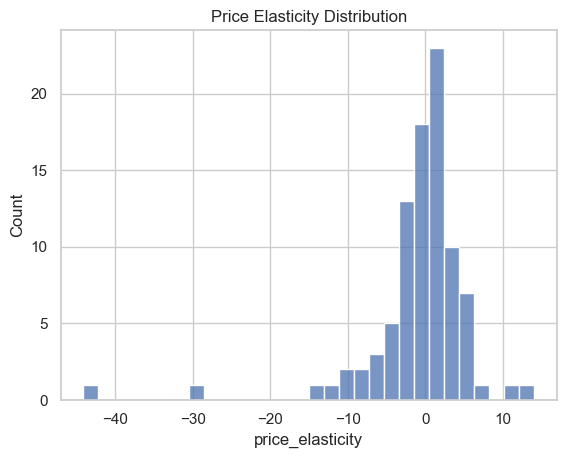

In [20]:
elastic = df.copy()

elastic["week"] = elastic["Booking_TS"].dt.to_period("W").astype(str)

weekly = elastic.groupby(["City", "Vehicle_Class", "week"], dropna=False).agg(
    bookings=("Reservation_ID", "count"),
    avg_rate=("Rate", "mean"),
    avg_lead_time=("lead_time_hours", "mean"),
).reset_index()

# NEW: Lead time segmentation
weekly["lead_time_bucket"] = pd.cut(
    weekly["avg_lead_time"],
    bins=[0, 6, 24, 72, 999],
    labels=["Last_Minute", "Short", "Medium", "Long"],
    include_lowest=True
)

def elasticity_proxy(g):
    g = g[(g["bookings"] > 0) & (g["avg_rate"] > 0)].dropna(subset=["bookings", "avg_rate"])

    if len(g) < 3 or g["avg_rate"].nunique() < 2:
        return np.nan

    x = np.log(g["avg_rate"])
    y = np.log(g["bookings"])

    return np.cov(x, y, bias=True)[0, 1] / (np.var(x) + 1e-9)


# UPDATED GROUPING
elasticity_table = (
    weekly.groupby(["City", "Vehicle_Class", "lead_time_bucket"], dropna=False)
    .apply(elasticity_proxy)
    .reset_index(name="price_elasticity")
)

print(elasticity_table.sort_values("price_elasticity").head(20))


# Visualization
sns.histplot(elasticity_table["price_elasticity"].dropna(), bins=30)
plt.title("Price Elasticity Distribution")
plt.show()

## 19) Fleet health score combining faults and usage


In [21]:
health_src = df.copy()
notes = health_src["Notes"].fillna("").str.lower()

health_src["fault_points"] = (
    np.where(health_src["Damage_Flag"].eq("Major"), 20, 0)
    + np.where(health_src["Damage_Flag"].eq("Minor"), 10, 0)
    + np.where(notes.str.contains("alert|malfunction|scratch"), 8, 0)
)

health_src["usage_hours_component"] = np.where(
    health_src["is_completed"],
    health_src["rental_hours"].fillna(0),
    0
)

health = health_src.groupby(["Vehicle_ID", "Vehicle_Class"], dropna=False).agg(
    fault_points=("fault_points", "sum"),
    usage_hours=("usage_hours_component", "sum"),
    avg_speed=("Speed", "mean"),
    rentals=("Reservation_ID", "count"),
).reset_index()

health["fault_norm"] = health["fault_points"] / (health["fault_points"].max() + 1e-9)
health["usage_norm"] = health["usage_hours"] / (health["usage_hours"].max() + 1e-9)

# UPDATED SPEED NORMALIZATION
max_speed = health["avg_speed"].max()
health["speed_norm"] = (health["avg_speed"].fillna(0) / max_speed).clip(0, 1)

health["fleet_health_score"] = 100 - (
    50 * health["fault_norm"] +
    30 * health["usage_norm"] +
    20 * health["speed_norm"]
)

health["fleet_health_score"] = health["fleet_health_score"].clip(0, 100)

health["health_band"] = pd.cut(
    health["fleet_health_score"],
    bins=[0, 50, 75, 100],
    labels=["Poor", "Moderate", "Healthy"],
    include_lowest=True
)

print(
    health[
        ["Vehicle_ID","Vehicle_Class","fleet_health_score","health_band"]
    ].head(20)
)

   Vehicle_ID Vehicle_Class  fleet_health_score health_band
0     CAR-001        Suzuki           69.812300    Moderate
1     CAR-002        Toyota           64.359952    Moderate
2     CAR-003     Hatchback           72.013281    Moderate
3     CAR-005           SUV           48.210240        Poor
4     CAR-006        Luxury           67.147275    Moderate
5     CAR-007        Toyota           73.526935    Moderate
6     CAR-008     Hatchback           65.272264    Moderate
7     CAR-009         Creta           76.644672     Healthy
8     CAR-010         Sedan           59.581324    Moderate
9     CAR-011        Luxury           70.471542    Moderate
10    CAR-012         Creta           54.873022    Moderate
11    CAR-013            EV           77.882782     Healthy
12    CAR-014     Hatchback           55.509802    Moderate
13    CAR-015         Sedan           55.578812    Moderate
14    CAR-016        Suzuki           75.673316     Healthy
15    CAR-017        Luxury           69

## 20) Churn likelihood for subscription rentals


Subscription proxy: customers with at least 3 bookings in the dataset are treated as subscription-like customers.


In [22]:
churn_src = df.copy()
churn_src["booking_date"] = churn_src["Booking_TS"].dt.floor("D")

cust_counts = churn_src.groupby("Customer_ID")["Reservation_ID"].count().rename("total_bookings")
subs = cust_counts[cust_counts >= 3].index
sub_df = churn_src[churn_src["Customer_ID"].isin(subs)].copy()

snapshot = sub_df["booking_date"].max() + pd.Timedelta(days=1) if not sub_df.empty else pd.Timestamp.today().normalize()

last_booking = sub_df.groupby("Customer_ID")["booking_date"].max().rename("last_booking")
sub_df["days_ago"] = (snapshot - sub_df["booking_date"]).dt.days

recent_90 = sub_df[sub_df["days_ago"] <= 90].groupby("Customer_ID")["Reservation_ID"].count().rename("bookings_recent_90")
prev_90 = sub_df[(sub_df["days_ago"] > 90) & (sub_df["days_ago"] <= 180)].groupby("Customer_ID")["Reservation_ID"].count().rename("bookings_prev_90")

churn = pd.concat([cust_counts, last_booking, recent_90, prev_90], axis=1).fillna(0)
churn = churn.loc[churn.index.isin(subs)].copy()

churn["days_since_last_booking"] = (snapshot - pd.to_datetime(churn["last_booking"])) .dt.days
churn["drop_ratio"] = np.where(churn["bookings_prev_90"] > 0, (churn["bookings_prev_90"] - churn["bookings_recent_90"]) / churn["bookings_prev_90"], 0)

churn["recency_norm"] = (churn["days_since_last_booking"] / 90).clip(0, 1)
churn["drop_norm"] = churn["drop_ratio"].clip(0, 1)
churn["churn_likelihood"] = (0.6 * churn["recency_norm"] + 0.4 * churn["drop_norm"]).clip(0, 1)
churn["churn_band"] = pd.cut(churn["churn_likelihood"], bins=[-0.01, 0.33, 0.66, 1.0], labels=["Low", "Medium", "High"])

print(churn.sort_values("churn_likelihood", ascending=False).head(20))
print("\nChurn Risk Distribution:")
print(churn["churn_band"].value_counts())


             total_bookings         last_booking  bookings_recent_90  \
Customer_ID                                                            
CUST-1997                 4  2025-06-20 00:00:00                 0.0   
CUST-0004                 3  2025-06-16 00:00:00                 0.0   
CUST-0007                 5  2025-06-24 00:00:00                 0.0   
CUST-0008                 3  2025-06-18 00:00:00                 0.0   
CUST-0011                 5  2025-06-17 00:00:00                 0.0   
CUST-0014                 4  2025-05-23 00:00:00                 0.0   
CUST-0015                 3  2025-06-15 00:00:00                 0.0   
CUST-0017                 4  2025-06-16 00:00:00                 0.0   
CUST-0018                 3  2025-05-16 00:00:00                 0.0   
CUST-1957                 5  2025-06-17 00:00:00                 0.0   
CUST-1953                 3  2025-07-06 00:00:00                 0.0   
CUST-1949                 5  2025-06-18 00:00:00                